# PBV Price-Level Vectors

Each of the 10 LOB size columns (`AskSize_1..5`, `BidSize_1..5`) gets its own independent scalar time series within each minute. That series is smoothed with a rolling mean (warmup period), then first and second derivatives are computed. The signal fires when the best ask is decelerating (`AskSize_1_d2 < 0`) and the best bid is accelerating (`BidSize_1_d2 > 0`), but only after the warmup window has filled. A fallback timer ensures execution by `FALLBACK_SECONDS`. Results are compared against TWAP (execution at `AskPrice_1` at tick 0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

STOCK            = "INTC"
SIDE             = "BUY"
FALLBACK_SECONDS = 50
WARMUP_TICKS     = 30      # rolling window; d1/d2 are NaN before this fills
L1_D2_THRESHOLD  = 0.0     # baseline signal threshold for best-level d2 comparisons
EPS              = 1e-6

LEVEL_COLS = [f"AskSize_{i}" for i in range(1, 6)] + [f"BidSize_{i}" for i in range(1, 6)]
EXEC_COL   = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"

df = pd.read_csv(f"training_datasets/{STOCK}_5levels_train.csv")
df["Time_dt"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f")
df["Minute"]  = df["Time_dt"].dt.floor("min")
df["elapsed"] = (df["Time_dt"] - df["Minute"]).dt.total_seconds()

print(df.shape, df["Minute"].nunique(), "minutes")

(430718, 36) 270 minutes


In [2]:
grp = df.groupby("Minute")

for col in LEVEL_COLS:
    df[f"{col}_cum"]    = grp[col].cumsum()
    df[f"{col}_smooth"] = grp[f"{col}_cum"].transform(
        lambda s: s.rolling(WARMUP_TICKS, min_periods=WARMUP_TICKS).mean()
    )
    df[f"{col}_d1"] = grp[f"{col}_smooth"].diff()
    df[f"{col}_d2"] = grp[f"{col}_d1"].diff()

CUM_COLS    = [f"{c}_cum"    for c in LEVEL_COLS]
SMOOTH_COLS = [f"{c}_smooth" for c in LEVEL_COLS]
D1_COLS     = [f"{c}_d1"     for c in LEVEL_COLS]
D2_COLS     = [f"{c}_d2"     for c in LEVEL_COLS]

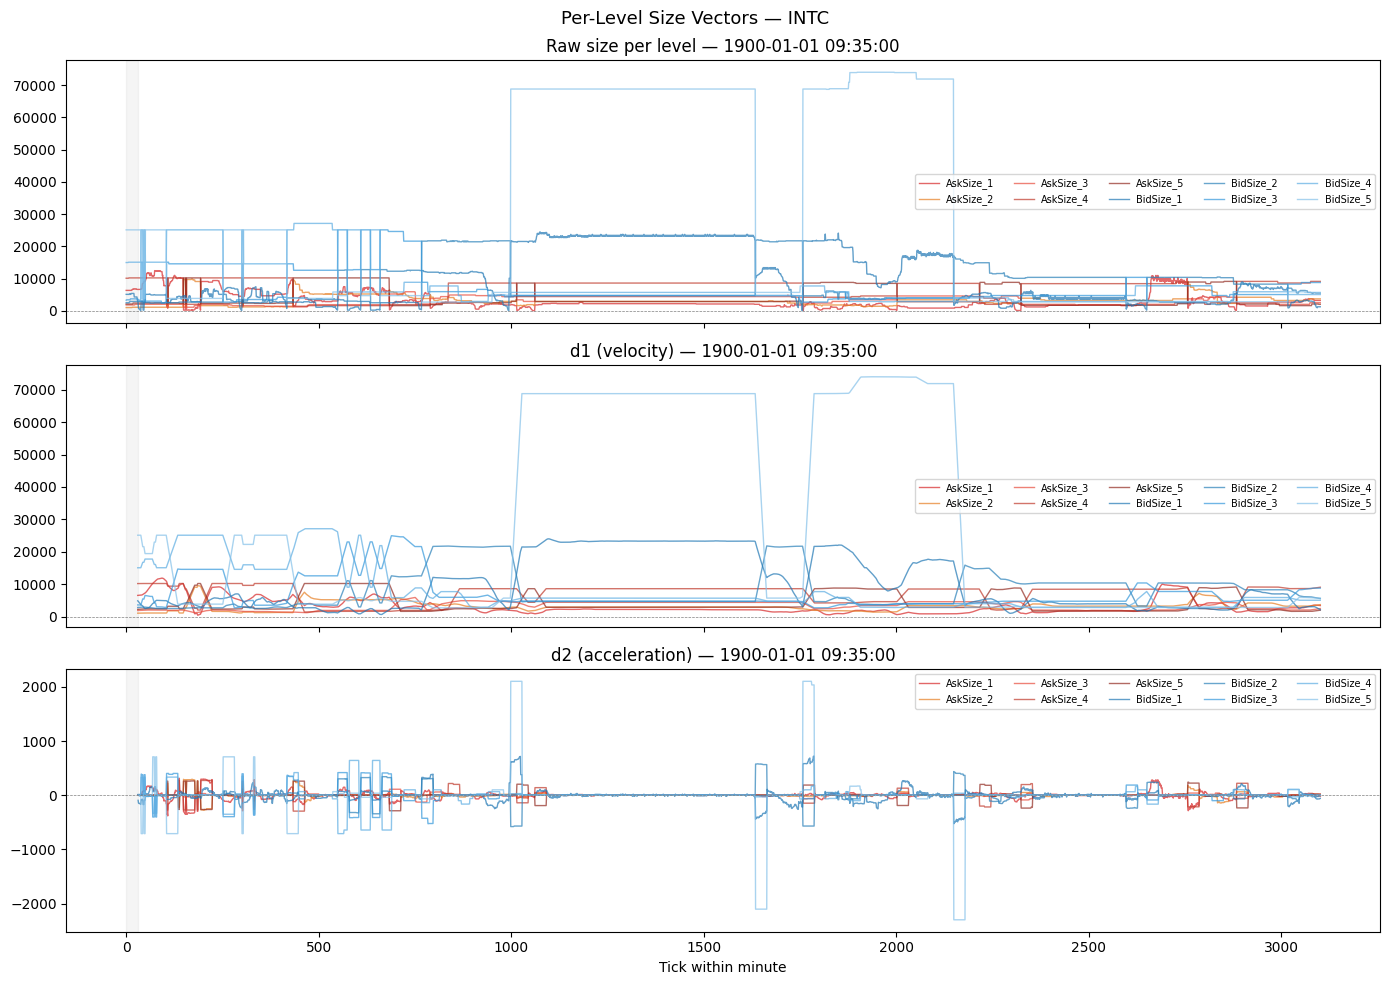

In [3]:
SAMPLE_MINUTE = df["Minute"].unique()[5]
sample = df[df["Minute"] == SAMPLE_MINUTE].reset_index(drop=True)

ask_colors = ["#d62728", "#e67e22", "#e74c3c", "#c0392b", "#922b21"]  # reds for ask
bid_colors = ["#1f77b4", "#2980b9", "#3498db", "#5dade2", "#85c1e9"]  # blues for bid
colors = ask_colors + bid_colors

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for col, c in zip(LEVEL_COLS, colors):
    label = col
    axes[0].plot(sample[col].values,            color=c, alpha=0.7, label=label, lw=1)
    axes[1].plot(sample[f"{col}_d1"].values,    color=c, alpha=0.7, label=label, lw=1)
    axes[2].plot(sample[f"{col}_d2"].values,    color=c, alpha=0.7, label=label, lw=1)

for ax, title in zip(axes, ["Raw size per level", "d1 (velocity)", "d2 (acceleration)"]):
    ax.set_title(f"{title} — {SAMPLE_MINUTE}")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(fontsize=7, ncol=5)
    ax.axvspan(0, WARMUP_TICKS, alpha=0.08, color="gray", label="warmup")

axes[2].set_xlabel("Tick within minute")
plt.suptitle(f"Per-Level Size Vectors — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
if SIDE == "BUY":
    df["signal"] = (df["AskSize_1_d2"] < -L1_D2_THRESHOLD) & (df["BidSize_1_d2"] > L1_D2_THRESHOLD)
else:
    df["signal"] = (df["BidSize_1_d2"] < -L1_D2_THRESHOLD) & (df["AskSize_1_d2"] > L1_D2_THRESHOLD)

df["signal"] = df["signal"].fillna(False)
df["signal"] = df["signal"] | (df["elapsed"] >= FALLBACK_SECONDS)

print(f"Side: {SIDE} | Exec col: {EXEC_COL} | Warmup: {WARMUP_TICKS} ticks | Fallback: {FALLBACK_SECONDS}s | L1 d2 threshold: {L1_D2_THRESHOLD}")
print(f"Signal fires on {df['signal'].sum()} rows ({100*df['signal'].mean():.1f}% of ticks)")

Side: BUY | Exec col: AskPrice_1 | Warmup: 30 ticks | Fallback: 50s | L1 d2 threshold: 0.0
Signal fires on 159675 rows (37.1% of ticks)


In [5]:
twap = df.groupby("Minute")[EXEC_COL].first().rename("twap_price")

first_signal_idx = df[df["signal"]].groupby("Minute").apply(lambda g: g.index[0])
exec_rows = df.loc[first_signal_idx, ["Minute", EXEC_COL, "elapsed"]].copy()
exec_rows.columns = ["Minute", "pbv_price", "exec_second"]
exec_rows = exec_rows.set_index("Minute")

results = twap.to_frame().join(exec_rows)
results["fallback"]    = results["exec_second"] >= FALLBACK_SECONDS
results["improvement"] = (
    (results["twap_price"] - results["pbv_price"]) if SIDE == "BUY"
    else (results["pbv_price"] - results["twap_price"])
)

_non_fb = results[~results["fallback"]]

print(f"{'='*50}")
print(f"  {STOCK} — {SIDE}")
print(f"  Minutes          : {len(results)}")
print(f"  Fallback         : {results['fallback'].sum()} ({100*results['fallback'].mean():.1f}%)")
print(f"  Mean improvement : {results['improvement'].mean():.5f}")
print(f"  Median improv.   : {results['improvement'].median():.5f}")
print(f"  % beating TWAP   : {100*(results['improvement'] > 0).mean():.1f}%")
print(f"  % non-fb beating : {100*(_non_fb['improvement'] > 0).mean():.1f}%  (n={len(_non_fb)})")
print(f"  Mean exec second : {results['exec_second'].mean():.1f}s")

  INTC — BUY
  Minutes          : 270
  Fallback         : 0 (0.0%)
  Mean improvement : 0.00044
  Median improv.   : 0.00000
  % beating TWAP   : 8.5%
  % non-fb beating : 8.5%  (n=270)
  Mean exec second : 4.9s


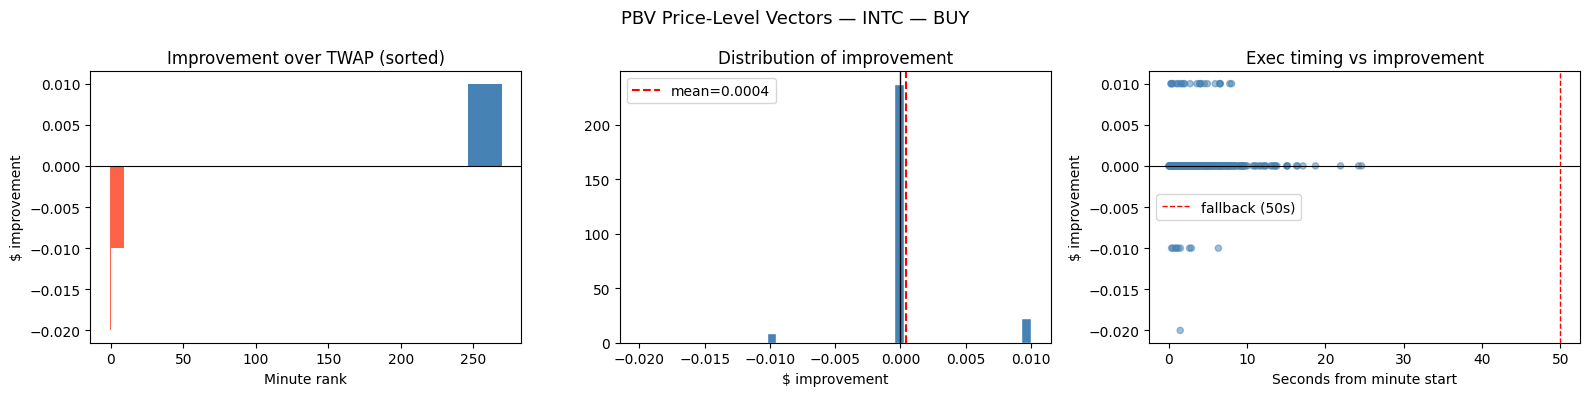

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sorted_imp = results["improvement"].sort_values()
axes[0].bar(range(len(sorted_imp)), sorted_imp.values,
            color=["steelblue" if v >= 0 else "tomato" for v in sorted_imp.values],
            width=1.0, edgecolor="none")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(title="Improvement over TWAP (sorted)", xlabel="Minute rank", ylabel="$ improvement")

axes[1].hist(results["improvement"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].axvline(results["improvement"].mean(), color="red", lw=1.5, ls="--",
                label=f"mean={results['improvement'].mean():.4f}")
axes[1].set(title="Distribution of improvement", xlabel="$ improvement")
axes[1].legend()

axes[2].scatter(results["exec_second"], results["improvement"],
                c=results["fallback"].map({True: "tomato", False: "steelblue"}),
                alpha=0.5, s=20)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].axvline(FALLBACK_SECONDS, color="red", lw=1, ls="--", label=f"fallback ({FALLBACK_SECONDS}s)")
axes[2].set(title="Exec timing vs improvement", xlabel="Seconds from minute start", ylabel="$ improvement")
axes[2].legend()

plt.suptitle(f"PBV Price-Level Vectors — {STOCK} — {SIDE}", fontsize=13)
plt.tight_layout()
plt.show()

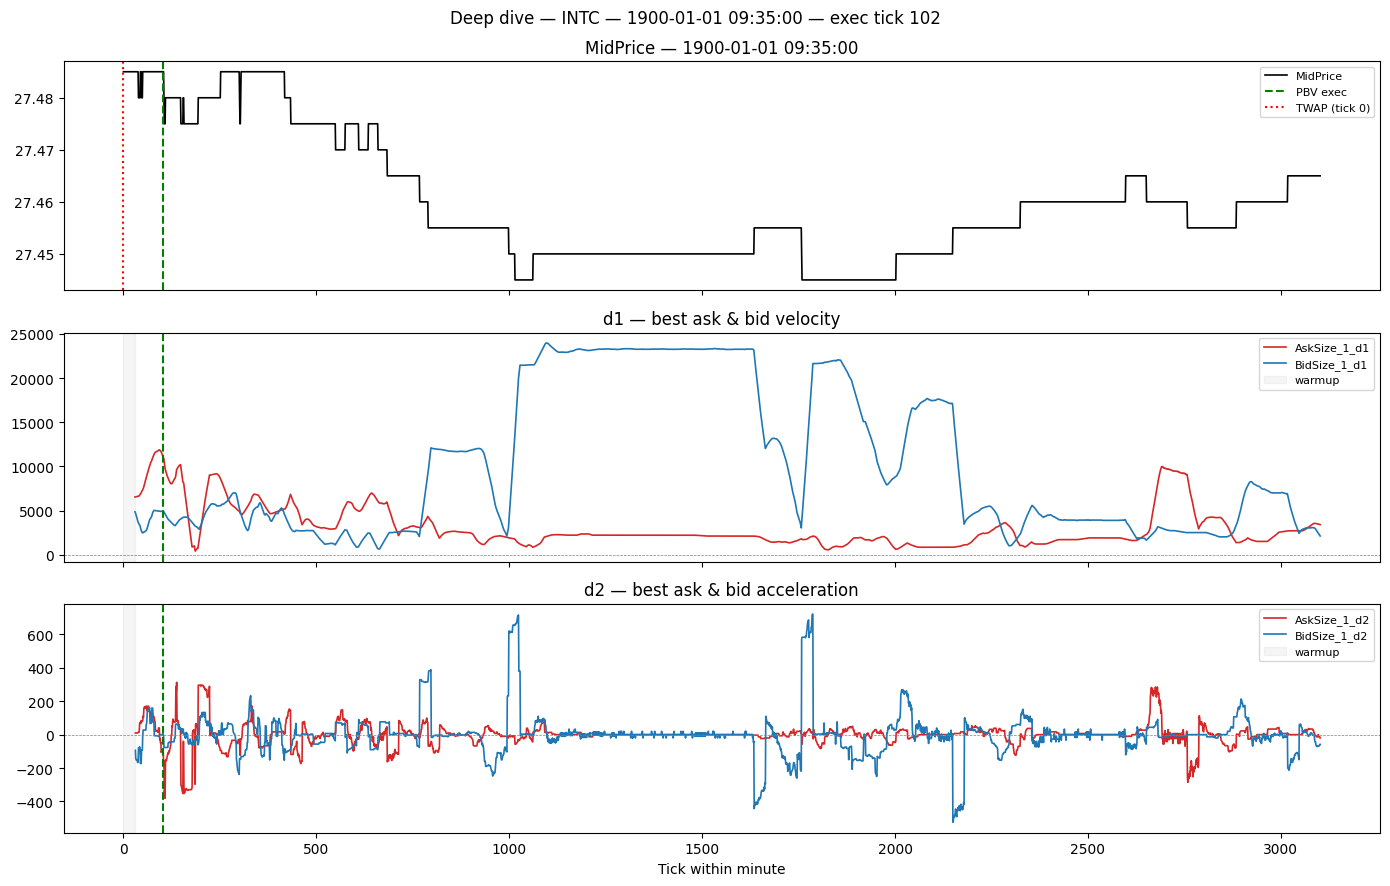

TWAP: 27.4900  PBV: 27.4900  Improvement: 0.0000


In [7]:
INSPECT_IDX    = 5
inspect_minute = df["Minute"].unique()[INSPECT_IDX]
sample         = df[df["Minute"] == inspect_minute].reset_index(drop=True)
fired_idx      = sample[sample["signal"]].index[0] if sample["signal"].any() else len(sample) - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(sample["MidPrice"].values, color="black", lw=1.2, label="MidPrice")
axes[0].axvline(fired_idx, color="green", ls="--", lw=1.5, label="PBV exec")
axes[0].axvline(0, color="red", ls=":", lw=1.5, label="TWAP (tick 0)")
axes[0].set_title(f"MidPrice — {inspect_minute}")
axes[0].legend(fontsize=8)

axes[1].plot(sample["AskSize_1_d1"].values, color="#d62728", lw=1.2, label="AskSize_1_d1")
axes[1].plot(sample["BidSize_1_d1"].values, color="#1f77b4", lw=1.2, label="BidSize_1_d1")
axes[1].axvline(fired_idx, color="green", ls="--", lw=1.5)
axes[1].axhline(0, color="gray", lw=0.5, ls="--")
axes[1].axvspan(0, WARMUP_TICKS, alpha=0.08, color="gray", label="warmup")
axes[1].set_title("d1 — best ask & bid velocity")
axes[1].legend(fontsize=8)

axes[2].plot(sample["AskSize_1_d2"].values, color="#d62728", lw=1.2, label="AskSize_1_d2")
axes[2].plot(sample["BidSize_1_d2"].values, color="#1f77b4", lw=1.2, label="BidSize_1_d2")
axes[2].axvline(fired_idx, color="green", ls="--", lw=1.5)
axes[2].axhline(0, color="gray", lw=0.5, ls="--")
axes[2].axvspan(0, WARMUP_TICKS, alpha=0.08, color="gray", label="warmup")
axes[2].set_title("d2 — best ask & bid acceleration")
axes[2].set_xlabel("Tick within minute")
axes[2].legend(fontsize=8)

plt.suptitle(f"Deep dive — {STOCK} — {inspect_minute} — exec tick {fired_idx}", fontsize=12)
plt.tight_layout()
plt.show()

twap_p = sample.iloc[0][EXEC_COL]
pbv_p  = sample.iloc[fired_idx][EXEC_COL]
print(f"TWAP: {twap_p:.4f}  PBV: {pbv_p:.4f}  Improvement: {twap_p - pbv_p:.4f}")

## Multi-Level d2 Composite Signal

Instead of only watching `AskSize_1_d2` / `BidSize_1_d2`, build a weighted composite score across all 5 levels, apply an adaptive rolling-percentile threshold, and require 2 consecutive confirming ticks before firing. The fallback remains at `FALLBACK_SECONDS`.

In [8]:
# ── Step 1: Weighted composite d2 scores ─────────────────────────────────────
# Level weights: level 1 = 5 (closest to mid), level 5 = 1 (furthest)
LEVEL_WEIGHTS = np.array([5, 4, 3, 2, 1], dtype=float)
LEVEL_WEIGHTS /= LEVEL_WEIGHTS.sum()   # normalise to sum = 1

ASK_D2_COLS = [f"AskSize_{i}_d2" for i in range(1, 6)]
BID_D2_COLS = [f"BidSize_{i}_d2" for i in range(1, 6)]

# Weighted sum across levels — fully vectorised (no apply)
ask_d2_mat = df[ASK_D2_COLS].values          # (N, 5)
bid_d2_mat = df[BID_D2_COLS].values          # (N, 5)

df["ask_score"] = ask_d2_mat @ LEVEL_WEIGHTS  # (N,)
df["bid_score"] = bid_d2_mat @ LEVEL_WEIGHTS  # (N,)

print("Composite score summary:")
df[["ask_score", "bid_score"]].describe().round(5)

Composite score summary:


,ask_score,bid_score
count,422348.00000,422348.00000
mean,0.05728,-0.05689
std,44.10143,48.80733
min,-843.08889,-977.68889
25%,-12.22222,-13.33333
50%,0.00000,0.00000
75%,10.17167,10.46000
max,837.80000,759.40000


In [9]:
# ── Step 2: Adaptive rolling-percentile threshold ────────────────────────────
# At each tick within a minute, threshold = Nth percentile of all |composite d2|
# values seen so far in that minute (expanding window, resets each minute).
# N=40 means: fire only when both scores exceed the 40th-percentile magnitude.
PERCENTILE_N = 40

# Combine ask_score and bid_score magnitudes into a single reference series.
df["abs_composite"] = (df["ask_score"].abs() + df["bid_score"].abs()) / 2.0

def expanding_percentile(s, q):
    """Expanding-window percentile within a group (vectorised via cumulative sort)."""
    arr = s.values.astype(float)
    out = np.empty(len(arr))
    out[:] = np.nan
    for k in range(len(arr)):
        window = arr[:k+1]
        valid  = window[~np.isnan(window)]
        out[k] = np.nanpercentile(valid, q) if len(valid) > 0 else np.nan
    return pd.Series(out, index=s.index)

# Per-minute expanding percentile — groupby transform
df["adaptive_thresh"] = (
    df.groupby("Minute")["abs_composite"]
      .transform(lambda s: expanding_percentile(s, PERCENTILE_N))
)

# Fill any NaN threshold with a fallback (first tick of minute has no history)
df["adaptive_thresh"] = df["adaptive_thresh"].fillna(df["abs_composite"].median())

print(f"Adaptive threshold stats (percentile={PERCENTILE_N}):")
df["adaptive_thresh"].describe().round(5)

Adaptive threshold stats (percentile=40):


count    430718.00000
mean         13.58551
std           7.75520
min           0.00000
25%           9.72889
50%          13.22222
75%          16.28711
max         170.45778
Name: adaptive_thresh, dtype: float64

In [10]:
# ── Step 3: Raw composite signal (threshold crossing) ────────────────────────
# BUY: ask wall softening (ask_score < -thresh) AND bid accelerating (bid_score > +thresh)
# Both sides must confirm simultaneously. Also gated by WARMUP_TICKS validity.

# Mark rows where d2 values are valid (past warmup window within the minute)
df["warmup_ok"] = df.groupby("Minute").cumcount() >= WARMUP_TICKS

df["raw_signal_new"] = (
    df["warmup_ok"]
    & (df["ask_score"] < -df["adaptive_thresh"])
    & (df["bid_score"] >  df["adaptive_thresh"])
)

# ── Step 4: Consecutive-tick filter (require 2 ticks in a row) ───────────────
# Shift by 1 within each minute so we don't leak across minute boundaries.
df["prev_raw_new"] = df.groupby("Minute")["raw_signal_new"].shift(1).fillna(False)
df["consec_signal_new"] = df["raw_signal_new"] & df["prev_raw_new"]

# ── Fallback: fire at FALLBACK_SECONDS regardless ────────────────────────────
df["signal_new"] = df["consec_signal_new"] | (df["elapsed"] >= FALLBACK_SECONDS)

print(f"Consecutive signal fires on {df['consec_signal_new'].sum()} rows "
      f"({100*df['consec_signal_new'].mean():.2f}% of ticks)")
print(f"With fallback OR: {df['signal_new'].sum()} rows "
      f"({100*df['signal_new'].mean():.2f}% of ticks)")

Consecutive signal fires on 26858 rows (6.24% of ticks)
With fallback OR: 94558 rows (21.95% of ticks)


In [11]:
# ── Step 5: Execution simulation & comparison ────────────────────────────────

def simulate_execution(signal_col, label):
    """Return a results DataFrame with improvement over TWAP for each minute."""
    first_idx = df[df[signal_col]].groupby("Minute").apply(lambda g: g.index[0])
    exec_rows  = df.loc[first_idx, ["Minute", EXEC_COL, "elapsed"]].copy()
    exec_rows.columns = ["Minute", "pbv_price", "exec_second"]
    exec_rows  = exec_rows.set_index("Minute")

    res = twap.to_frame().join(exec_rows)
    res["fallback"]    = res["exec_second"] >= FALLBACK_SECONDS
    res["improvement"] = res["twap_price"] - res["pbv_price"]  # BUY: lower price = positive
    res["label"]       = label
    return res

results_old = simulate_execution("signal",     "Basic d2 (L1 only)")
results_new = simulate_execution("signal_new", "Multi-level composite d2")

def print_summary(res, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  Minutes          : {len(res)}")
    print(f"  Fallback         : {res['fallback'].sum()} ({100*res['fallback'].mean():.1f}%)")
    print(f"  Mean improvement : ${res['improvement'].mean():.5f}")
    print(f"  Median improv.   : ${res['improvement'].median():.5f}")
    print(f"  % beating TWAP   : {100*(res['improvement'] > 0).mean():.1f}%")
    print(f"  Mean exec second : {res['exec_second'].mean():.1f}s")

print_summary(results_old, "Basic d2 (L1 only) — BASELINE")
print_summary(results_new, "Multi-level composite d2 — NEW")


  Basic d2 (L1 only) — BASELINE
  Minutes          : 270
  Fallback         : 0 (0.0%)
  Mean improvement : $0.00044
  Median improv.   : $0.00000
  % beating TWAP   : 8.5%
  Mean exec second : 4.9s

  Multi-level composite d2 — NEW
  Minutes          : 270
  Fallback         : 2 (0.7%)
  Mean improvement : $0.00204
  Median improv.   : $0.00000
  % beating TWAP   : 23.3%
  Mean exec second : 11.5s


/tmp/ipykernel_34296/3931270045.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


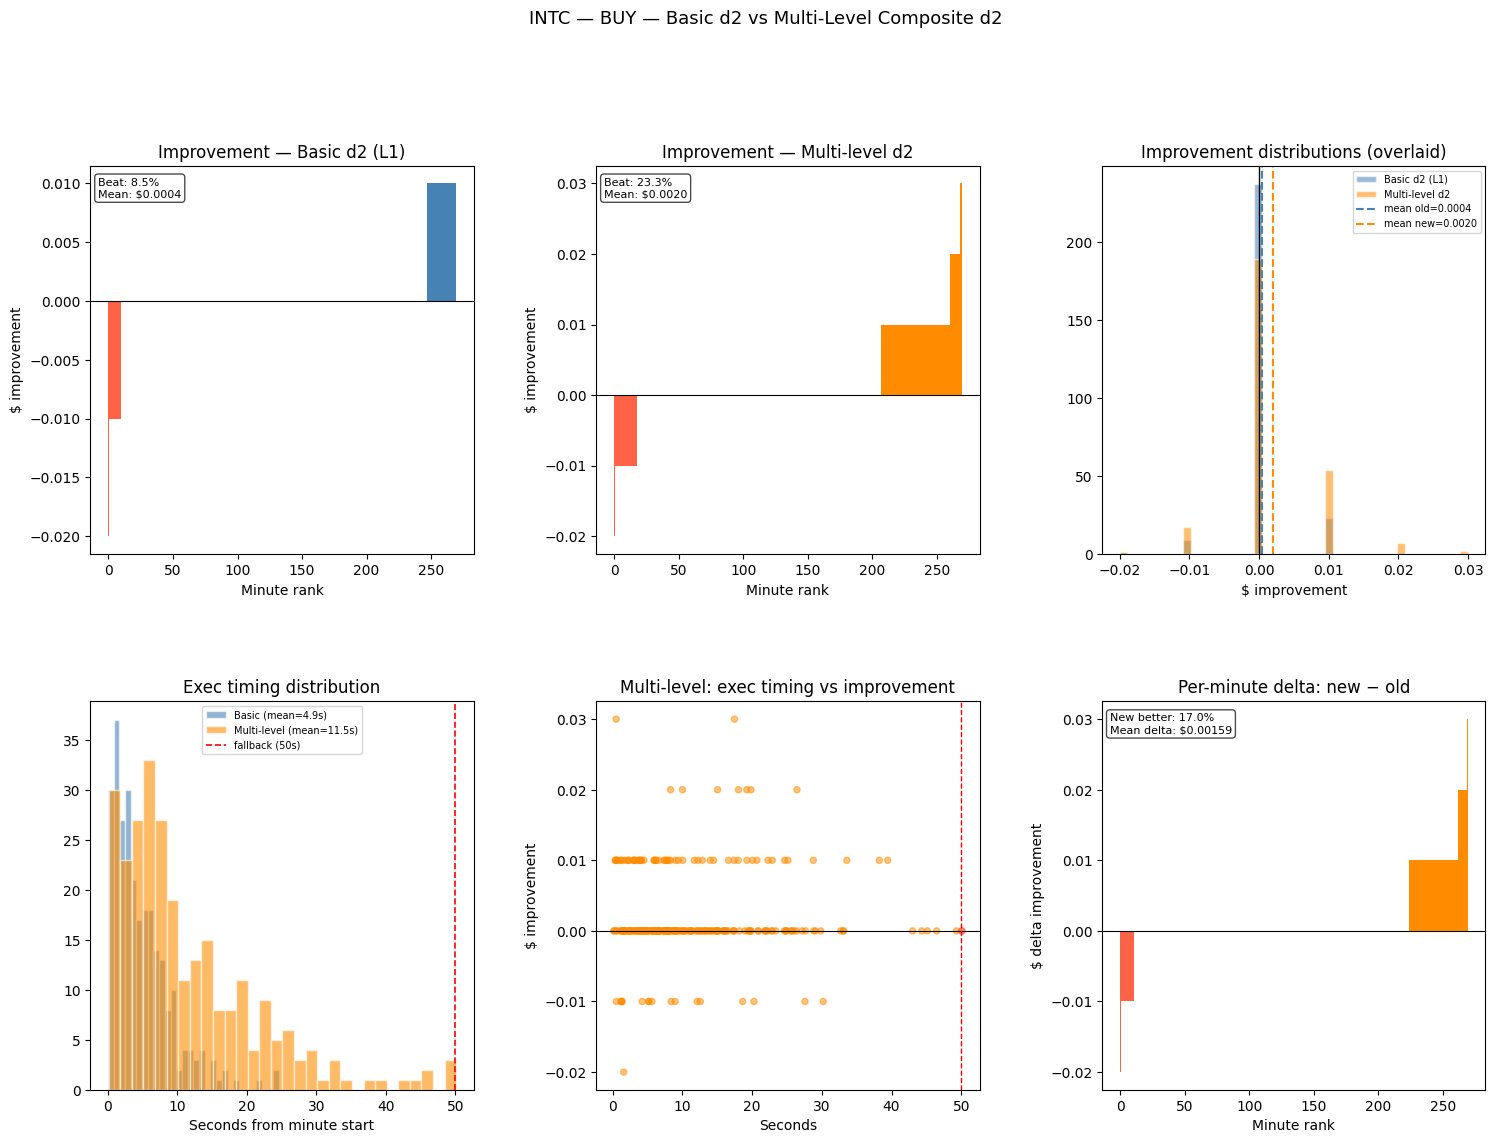

In [12]:
# ── Step 6: Visualisation ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

ax_bar_old = fig.add_subplot(gs[0, 0])
ax_bar_new = fig.add_subplot(gs[0, 1])
ax_dist    = fig.add_subplot(gs[0, 2])
ax_timing  = fig.add_subplot(gs[1, 0])
ax_scatter = fig.add_subplot(gs[1, 1])
ax_delta   = fig.add_subplot(gs[1, 2])

# ── Sorted improvement bars ──
for ax, res, title, clr in [
    (ax_bar_old, results_old, "Improvement — Basic d2 (L1)", "steelblue"),
    (ax_bar_new, results_new, "Improvement — Multi-level d2", "darkorange"),
]:
    s = res["improvement"].sort_values()
    ax.bar(range(len(s)), s.values,
           color=[clr if v >= 0 else "tomato" for v in s.values],
           width=1.0, edgecolor="none")
    ax.axhline(0, color="black", lw=0.8)
    ax.set(title=title, xlabel="Minute rank", ylabel="$ improvement")
    ax.text(0.02, 0.97, f"Beat: {100*(res['improvement']>0).mean():.1f}%\n"
                        f"Mean: ${res['improvement'].mean():.4f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# ── Overlaid distribution ──
bins = np.linspace(
    min(results_old["improvement"].min(), results_new["improvement"].min()),
    max(results_old["improvement"].max(), results_new["improvement"].max()),
    45
)
ax_dist.hist(results_old["improvement"], bins=bins, alpha=0.55,
             color="steelblue", label="Basic d2 (L1)", edgecolor="white")
ax_dist.hist(results_new["improvement"], bins=bins, alpha=0.55,
             color="darkorange", label="Multi-level d2", edgecolor="white")
ax_dist.axvline(0, color="black", lw=1)
ax_dist.axvline(results_old["improvement"].mean(), color="steelblue",
                lw=1.5, ls="--", label=f"mean old={results_old['improvement'].mean():.4f}")
ax_dist.axvline(results_new["improvement"].mean(), color="darkorange",
                lw=1.5, ls="--", label=f"mean new={results_new['improvement'].mean():.4f}")
ax_dist.set(title="Improvement distributions (overlaid)", xlabel="$ improvement")
ax_dist.legend(fontsize=7)

# ── Exec timing distributions ──
ax_timing.hist(results_old["exec_second"], bins=30, alpha=0.6,
               color="steelblue", label=f"Basic (mean={results_old['exec_second'].mean():.1f}s)",
               edgecolor="white")
ax_timing.hist(results_new["exec_second"], bins=30, alpha=0.6,
               color="darkorange", label=f"Multi-level (mean={results_new['exec_second'].mean():.1f}s)",
               edgecolor="white")
ax_timing.axvline(FALLBACK_SECONDS, color="red", lw=1.2, ls="--",
                  label=f"fallback ({FALLBACK_SECONDS}s)")
ax_timing.set(title="Exec timing distribution", xlabel="Seconds from minute start")
ax_timing.legend(fontsize=7)

# ── Scatter: exec second vs improvement (new algorithm) ──
ax_scatter.scatter(results_new["exec_second"], results_new["improvement"],
                   c=results_new["fallback"].map({True: "tomato", False: "darkorange"}),
                   alpha=0.5, s=20)
ax_scatter.axhline(0, color="black", lw=0.8)
ax_scatter.axvline(FALLBACK_SECONDS, color="red", lw=1, ls="--")
ax_scatter.set(title="Multi-level: exec timing vs improvement",
               xlabel="Seconds", ylabel="$ improvement")

# ── Per-minute delta: new vs old improvement ──
delta = results_new["improvement"] - results_old["improvement"]
delta_s = delta.sort_values()
ax_delta.bar(range(len(delta_s)), delta_s.values,
             color=["darkorange" if v >= 0 else "tomato" for v in delta_s.values],
             width=1.0, edgecolor="none")
ax_delta.axhline(0, color="black", lw=0.8)
ax_delta.set(title="Per-minute delta: new − old", xlabel="Minute rank",
             ylabel="$ delta improvement")
ax_delta.text(0.02, 0.97,
              f"New better: {100*(delta>0).mean():.1f}%\nMean delta: ${delta.mean():.5f}",
              transform=ax_delta.transAxes, va="top", fontsize=8,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.suptitle(f"{STOCK} — {SIDE} — Basic d2 vs Multi-Level Composite d2", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Running pipeline on all stocks...
Done.

  Cross-stock summary — BUY side
       Minutes Basic mean $ Basic beat % Basic exec s Composite mean $ Composite beat % Composite exec s
Stock                                                                                                   
AMZN       270      0.01052         54.1         12.1          0.01170             52.6             17.9
GOOG       270      0.00156         54.4         14.9          0.00448             51.9             28.4
INTC       270      0.00044          8.5          4.9          0.00204             23.3             11.5
MSFT       270      0.00096         11.9          6.1          0.00267             27.0             13.6


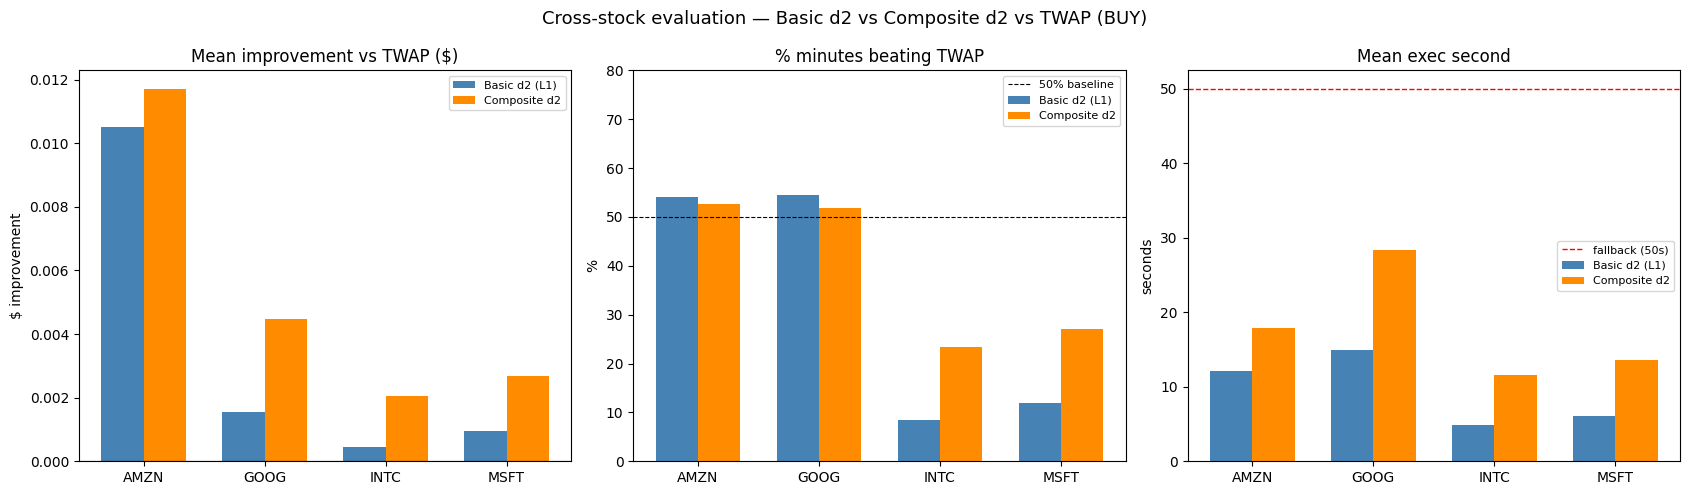

In [13]:
# ── Cross-stock evaluation: Basic d2 vs Multi-level composite d2 vs TWAP ──────
# Runs the full pipeline independently for each stock and collects summary stats.

STOCKS       = ["AMZN", "GOOG", "INTC", "MSFT"]
_EXEC_COL    = "AskPrice_1"
_WARMUP      = 30
_FALLBACK    = 50
_PERC        = 40
_WEIGHTS     = np.array([5, 4, 3, 2, 1], dtype=float)
_WEIGHTS    /= _WEIGHTS.sum()
_LEVEL_COLS  = [f"AskSize_{i}" for i in range(1, 6)] + [f"BidSize_{i}" for i in range(1, 6)]
_ASK_D2      = [f"AskSize_{i}_d2" for i in range(1, 6)]
_BID_D2      = [f"BidSize_{i}_d2" for i in range(1, 6)]

def run_stock(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()

    grp = d.groupby("Minute")
    for col in _LEVEL_COLS:
        d[f"{col}_cum"]    = grp[col].cumsum()
        d[f"{col}_smooth"] = grp[f"{col}_cum"].transform(
            lambda s: s.rolling(_WARMUP, min_periods=_WARMUP).mean()
        )
        d[f"{col}_d1"] = grp[f"{col}_smooth"].diff()
        d[f"{col}_d2"] = grp[f"{col}_d1"].diff()

    # Basic signal (L1 only)
    d["signal_basic"] = (
        (d["AskSize_1_d2"] < 0) & (d["BidSize_1_d2"] > 0)
    ).fillna(False) | (d["elapsed"] >= _FALLBACK)

    # Composite scores
    d["ask_score"] = d[_ASK_D2].values @ _WEIGHTS
    d["bid_score"] = d[_BID_D2].values @ _WEIGHTS
    d["abs_comp"]  = (d["ask_score"].abs() + d["bid_score"].abs()) / 2.0

    def _exp_pct(s):
        arr = s.values.astype(float)
        out = np.empty(len(arr))
        for k in range(len(arr)):
            valid = arr[:k+1][~np.isnan(arr[:k+1])]
            out[k] = np.nanpercentile(valid, _PERC) if len(valid) else np.nan
        return pd.Series(out, index=s.index)

    d["thresh"]     = d.groupby("Minute")["abs_comp"].transform(_exp_pct)
    d["thresh"]     = d["thresh"].fillna(d["abs_comp"].median())
    d["warmup_ok"]  = d.groupby("Minute").cumcount() >= _WARMUP
    d["raw_new"]    = d["warmup_ok"] & (d["ask_score"] < -d["thresh"]) & (d["bid_score"] > d["thresh"])
    d["prev_new"]   = d.groupby("Minute")["raw_new"].shift(1).fillna(False)
    d["signal_new"] = (d["raw_new"] & d["prev_new"]) | (d["elapsed"] >= _FALLBACK)

    twap_s = d.groupby("Minute")[_EXEC_COL].first().rename("twap_price")

    def _sim(sig_col):
        fi  = d[d[sig_col]].groupby("Minute").apply(lambda g: g.index[0])
        er  = d.loc[fi, ["Minute", _EXEC_COL, "elapsed"]].copy()
        er.columns = ["Minute", "pbv_price", "exec_second"]
        er  = er.set_index("Minute")
        res = twap_s.to_frame().join(er)
        res["fallback"]    = res["exec_second"] >= _FALLBACK
        res["improvement"] = res["twap_price"] - res["pbv_price"]
        return res

    r_basic = _sim("signal_basic")
    r_new   = _sim("signal_new")
    return {
        "stock": stock, "minutes": len(r_basic),
        "basic_mean": r_basic["improvement"].mean(),
        "basic_beat": (r_basic["improvement"] > 0).mean() * 100,
        "basic_exec_s": r_basic["exec_second"].mean(),
        "comp_mean": r_new["improvement"].mean(),
        "comp_beat": (r_new["improvement"] > 0).mean() * 100,
        "comp_exec_s": r_new["exec_second"].mean(),
        "r_basic": r_basic, "r_new": r_new,
    }

print("Running pipeline on all stocks...")
stock_results = {s: run_stock(s) for s in STOCKS}
print("Done.")

# Summary table
rows = []
for s, r in stock_results.items():
    rows.append({
        "Stock": s, "Minutes": r["minutes"],
        "Basic mean $": f"{r['basic_mean']:.5f}",
        "Basic beat %": f"{r['basic_beat']:.1f}",
        "Basic exec s": f"{r['basic_exec_s']:.1f}",
        "Composite mean $": f"{r['comp_mean']:.5f}",
        "Composite beat %": f"{r['comp_beat']:.1f}",
        "Composite exec s": f"{r['comp_exec_s']:.1f}",
    })

summary = pd.DataFrame(rows).set_index("Stock")
print("\n" + "="*75)
print("  Cross-stock summary — BUY side")
print("="*75)
print(summary.to_string())

# Grouped bar chart
x     = np.arange(len(STOCKS))
width = 0.35
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

basic_means = [stock_results[s]["basic_mean"] for s in STOCKS]
comp_means  = [stock_results[s]["comp_mean"]  for s in STOCKS]
axes[0].bar(x - width/2, basic_means, width, label="Basic d2 (L1)", color="steelblue")
axes[0].bar(x + width/2, comp_means,  width, label="Composite d2",  color="darkorange")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(STOCKS)
axes[0].set(title="Mean improvement vs TWAP ($)", ylabel="$ improvement")
axes[0].legend(fontsize=8)

basic_beat = [stock_results[s]["basic_beat"] for s in STOCKS]
comp_beat  = [stock_results[s]["comp_beat"]  for s in STOCKS]
axes[1].bar(x - width/2, basic_beat, width, label="Basic d2 (L1)", color="steelblue")
axes[1].bar(x + width/2, comp_beat,  width, label="Composite d2",  color="darkorange")
axes[1].axhline(50, color="black", lw=0.8, ls="--", label="50% baseline")
axes[1].set_xticks(x); axes[1].set_xticklabels(STOCKS)
axes[1].set(title="% minutes beating TWAP", ylabel="%", ylim=(0, 80))
axes[1].legend(fontsize=8)

basic_exec = [stock_results[s]["basic_exec_s"] for s in STOCKS]
comp_exec  = [stock_results[s]["comp_exec_s"]  for s in STOCKS]
axes[2].bar(x - width/2, basic_exec, width, label="Basic d2 (L1)", color="steelblue")
axes[2].bar(x + width/2, comp_exec,  width, label="Composite d2",  color="darkorange")
axes[2].axhline(_FALLBACK, color="red", lw=1, ls="--", label=f"fallback ({_FALLBACK}s)")
axes[2].set_xticks(x); axes[2].set_xticklabels(STOCKS)
axes[2].set(title="Mean exec second", ylabel="seconds")
axes[2].legend(fontsize=8)

plt.suptitle("Cross-stock evaluation — Basic d2 vs Composite d2 vs TWAP (BUY)", fontsize=13)
plt.tight_layout()
plt.show()
